# Predicción del Mundial 2026 mediante Modelos XGBoost y Simulación Monte Carlo

**Resumen.** Se presenta un pipeline de aprendizaje automático para predecir resultados de partidos de fútbol internacional y estimar las probabilidades de cada selección de ganar el Mundial de la FIFA 2026. El sistema combina dos regresores XGBoost con distribución Tweedie para proyectar los goles esperados de cada equipo, un clasificador XGBoost con calibración isotónica para obtener probabilidades 1X2 bien calibradas, y una simulación Monte Carlo de $N = 1{,}000$ torneos para propagar la incertidumbre a través del cuadro eliminatorio. La fase de grupos ya fue disputada; las simulaciones parten de los 16 cruces reales de dieciseisavos de final.



In [1]:
from google.colab import drive
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Simulaciones_Mundial/Data'

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

## 1. Carga y Descripción del Dataset

El dataset `datos_historicos.csv` contiene una fila por partido disputado por selecciones nacionales, con las estadísticas de ambos equipos. Las variables se construyeron en una fase previa de *feature engineering* e incluyen:

- **Medias móviles** (ventana de 5 partidos e histórico completo) de goles marcados/encajados, xG, posesión, remates a puerta, córneres, faltas y paradas.
- **Diferencias y ratios** entre equipos para cada estadística anterior.
- **Indicadores de forma** basados en puntos Elo/FIFA: diferencia de puntos, probabilidad implícita del Elo, *tiers* de nivel (1–4) y pesos por confederación.

Tras eliminar filas con valores ausentes —principalmente el primer partido de cada selección, donde las medias móviles no tienen historia suficiente— la matriz resultante tiene aproximadamente $n \approx 1{,}400$ observaciones y $p = 45$ covariables.

$$\mathbf{X} \in \mathbb{R}^{n \times p}, \quad \mathbf{y} \in \{0, 1, 2\}^n$$

In [3]:
df = pd.read_csv(f'{base_path}/datos_historicos.csv')
df.sort_values('Fecha', inplace=True)

model_cols = df.columns

# Eliminamos filas con datos faltantes (basicamente el primer partido de cada seleccion tiene las variables a Null al hacer las medias moviles)
df.dropna(inplace=True)

df.head()

,Fecha,Equipo_Local,Equipo_Visitante,Goles_Local,Goles_Visitante,Peso_Local,avg_Goles_esperados_(xG)_total_Local,avg_Tarjetas_amarillas_total_Local,avg_Faltas_total_Local,avg_Remates_a_puerta_3_Local,...,diff_avg_Córneres_3,diff_avg_Tarjetas_amarillas_3,diff_avg_Faltas_3,diff_avg_Paradas_3,diff_avg_Pases_Pct_3,diff_avg_Pases_Exitosos_3,diff_Puntos,Prob_Implicita_ELO,diff_Tier,diff_Valor_Mercado
533,2023-03-28,Turquía,Croacia,0.0,2.0,1.0,0.720,2.166667,11.444444,5.666667,...,-2.333333,1.000000,1.000000,0.000000,-0.050000,-44.333333,-262.24,0.181002,3,3.32
535,2023-03-28,Escocia,España,2.0,0.0,1.0,1.790,1.764706,10.833333,3.333333,...,2.666667,2.333333,2.666667,1.333333,-0.096667,-501.000000,-215.77,0.224076,2,-40.48
536,2023-06-14,Países Bajos,Croacia,2.0,2.0,1.0,3.515,1.681818,12.521739,6.000000,...,3.666667,1.333333,6.000000,0.666667,0.020000,109.333333,1.21,0.501741,0,14.11
543,2023-06-17,Bélgica,Austria,1.0,1.0,1.0,2.720,1.352941,9.333333,4.333333,...,2.333333,-0.333333,-2.000000,1.333333,0.100000,215.333333,284.29,0.837059,-2,11.63
544,2023-06-17,Noruega,Escocia,1.0,2.0,1.0,1.350,1.722222,11.166667,3.000000,...,0.666667,-1.666667,-2.333333,0.333333,0.073333,174.333333,-36.75,0.447309,1,16.14


La variable dependiente se codifica numéricamente para que el modelo la pueda procesar.

## 2. Transformación de la Variable Dependiente

El resultado categórico $\{1, X, 2\}$ se codifica como variable ordinal:

$$Y \in \{0 = \text{Victoria Local},\; 1 = \text{Empate},\; 2 = \text{Victoria Visitante}\}$$

La distribución empírica de clases en el dataset histórico es aproximadamente $45\%$ victorias locales, $26\%$ empates y $29\%$ victorias visitantes, reflejando la ventaja de campo propia del fútbol internacional.

In [4]:
# 1. Definimos el diccionario de traducción
mapeo_resultados = {
    '1': 0,  # Victoria Local
    'X': 1,  # Empate
    '2': 2   # Victoria Visitante
}

# 2. Aplicamos la traducción creando una nueva columna numérica
df['Resultado_1X2_Num'] = df['Resultado_1X2'].map(mapeo_resultados)

# 3. Ahora definimos 'y' apuntando a esta nueva columna
y = df['Resultado_1X2_Num']

Se construye la matriz de covariables eliminando las columnas no predictivas.

## 3. Matriz de Covariables $\mathbf{X}$

Se eliminan del dataset las columnas no predictivas (`Fecha`, identificadores de equipo, goles reales observados y resultado) y el resto forma la matriz $\mathbf{X}$ de entrada al modelo:

$$\mathbf{X} = \mathbf{D} \setminus \{\text{Fecha},\; \text{Equipo\_Local},\; \text{Equipo\_Visitante},\; \text{Resultado},\; \text{Goles\_Local},\; \text{Goles\_Visitante}\}$$

Las variables de goles reales se excluyen explícitamente para evitar *data leakage*: en producción no se conocen antes del partido.

In [5]:
X = df.drop(columns=['Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado_1X2', 'Resultado_1X2_Num', 'Goles_Local', 'Goles_Visitante'])
X.columns

Index(['Peso_Local', 'avg_Goles_esperados_(xG)_total_Local',
       'avg_Tarjetas_amarillas_total_Local', 'avg_Faltas_total_Local',
       'avg_Remates_a_puerta_3_Local', 'avg_Córneres_3_Local',
       'avg_Tarjetas_amarillas_3_Local', 'avg_Faltas_3_Local',
       'avg_Paradas_3_Local', 'avg_Pases_Pct_3_Local',
       'avg_Pases_Exitosos_3_Local', 'Peso_Visitante',
       'avg_Goles_esperados_(xG)_total_Visitante',
       'avg_Tarjetas_amarillas_total_Visitante', 'avg_Faltas_total_Visitante',
       'avg_Pases_Pct_total_Visitante', 'avg_xG_Share_total_Visitante',
       'avg_Goles_esperados_(xG)_3_Visitante',
       'avg_Remates_a_puerta_3_Visitante', 'avg_Córneres_3_Visitante',
       'avg_Tarjetas_amarillas_3_Visitante', 'avg_Faltas_3_Visitante',
       'avg_Paradas_3_Visitante', 'avg_Pases_Exitosos_3_Visitante',
       'avg_Goles_3_Visitante', 'avg_Ptos_3_Visitante',
       'avg_xG_Share_3_Visitante', 'avg_Paradas_Share_3_Visitante',
       'diff_avg_Tarjetas_amarillas_total', 'diff

# Ajuste del Modelo


## 4. Estrategia de Modelado: *Stacking* en Dos Fases

Se adopta una arquitectura de *stacking* que separa la predicción de magnitud (goles) de la predicción de resultado (1X2), usando las primeras como meta-variables de las segundas para transferir información de escala al clasificador.

---

### 4.1 Partición Temporal

Para respetar la causalidad temporal y evitar que el modelo "vea el futuro", la división train/test se realiza por corte cronológico:

$$\mathcal{D}_{\text{train}} = \{t \mid t \leq t_{85\%}\}, \qquad \mathcal{D}_{\text{test}} = \{t \mid t > t_{85\%}\}$$

La validación cruzada interna también es temporal (`TimeSeriesSplit` con $k=5$ folds), de modo que cada fold valida sobre partidos posteriores a su conjunto de entrenamiento.

---

### 4.2 Fase 1 — Regresores de Goles (XGBoost Tweedie)

Se ajustan dos modelos independientes $f_L$ y $f_V$ —uno para goles del equipo local y otro para el visitante— bajo una distribución Tweedie:

$$\mathbb{E}[\text{Goles}] = \exp(\mathbf{x}^\top \boldsymbol{\beta}), \qquad \text{Var}[\text{Goles}] \propto \mu^{p}, \quad p = 1.5$$

El exponente $p = 1.5$ es el punto medio entre Poisson ($p = 1$, varianza $= \mu$) y Gamma ($p = 2$, varianza $= \mu^2$), adecuado para datos de fútbol que presentan sobredispersión moderada respecto a Poisson pero no tanta como Gamma.

Para que los partidos de alta goleada —estadísticamente raros pero informativos— no queden sistemáticamente subestimados, se asignan pesos de muestra:

$$w_i = \begin{cases} 1.5 & \text{si } \text{Goles}_i \geq 3 \\ 1.0 & \text{en otro caso} \end{cases}$$

Los hiperparámetros $\{\text{n\_estimators},\, \text{learning\_rate},\, \text{max\_depth},\, \text{subsample},\, \lambda,\, \gamma,\, \text{colsample\_bytree}\}$ se buscan con `RandomizedSearchCV` (`n_iter=50`, `TimeSeriesSplit`, métrica `neg_mean_poisson_deviance`).

Las predicciones sobre el conjunto de entrenamiento se generan **out-of-fold** (5 folds) para evitar *data leakage* en la fase siguiente, y se transforman para obtener los goles esperados ajustados por contexto geográfico:

$$\hat{\lambda}_i = \hat{f}(\mathbf{x}_i)^{1.5} \cdot w_{\text{confederación},\, i}$$

---

### 4.3 Fase 2 — Clasificador 1X2 (XGBoost + Calibración Isotónica)

Las proyecciones $\hat{\lambda}_L$ y $\hat{\lambda}_V$ se incorporan como meta-variables a $\mathbf{X}$, formando la matriz aumentada $\mathbf{X}_{\text{meta}}$. Sobre ella se entrena un clasificador multiclase:

$$P(Y = k \mid \mathbf{X}_{\text{meta}}) = \text{softmax}_k(\mathbf{X}_{\text{meta}}), \qquad k \in \{0, 1, 2\}$$

con `objective='multi:softprob'` y búsqueda de hiperparámetros con `RandomizedSearchCV` (`n_iter=100`, `TimeSeriesSplit`).

Los árboles de decisión tienden a producir probabilidades extremas (sobreconfianza). Para corregirlo se aplica **calibración isotónica** sobre las probabilidades brutas:

$$\tilde{p}_k = g^{-1}(p_k)$$

donde $g$ es una función monótona no paramétrica estimada por `CalibratedClassifierCV(method='isotonic', cv=TimeSeriesSplit)`. La calibración isotónica es preferible a la de Platt (sigmoide) cuando el número de muestras es suficiente, ya que no impone forma funcional sobre la corrección.


In [6]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_val_predict
from sklearn.metrics import classification_report
from sklearn.model_selection import KFold
from sklearn.calibration import CalibratedClassifierCV

# 1. Split Temporal (85% Train, 15% Test)
split_index = int(len(df) * 0.85)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train_1X2, y_test_1X2 = y.iloc[:split_index], y.iloc[split_index:]
df_train, df_test = df.iloc[:split_index].copy(), df.iloc[split_index:].copy()  # Copias para evitar SettingWithCopyWarning

# Variables de interes de goles
y_train_goles_L = df['Goles_Local'].iloc[:split_index]
y_train_goles_V = df['Goles_Visitante'].iloc[:split_index]
y_test_goles_L = df['Goles_Local'].iloc[split_index:]
y_test_goles_V = df['Goles_Visitante'].iloc[split_index:]

# 2. Configuración de Validación Cruzada Temporal
# Esto evita mezclar el futuro con el pasado durante la búsqueda de hiperparámetros
tscv = TimeSeriesSplit(n_splits=5)

In [7]:
# =====================================================================
# OPTIMIZACIÓN: n_iter reducido drásticamente + early_stopping en XGBoost
# n_iter=50/100
# El early_stopping corta árboles inútiles sin perder calidad de búsqueda.
# =====================================================================

# 3. Espacio de búsqueda de hiperparámetros
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.005, 0.01, 0.05, 0.1, 0.2, 0.5],
    'max_depth': [2, 3, 5, 8],
    'subsample': [0.8, 0.9, 1.0],
    'reg_lambda': [0.1, 0.5, 1.0, 5.0],
    'gamma': [0, 0.1],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

print("Fase 1: Entrenando predictores de Goles (Poisson)...")

# --- Creación de pesos (Partidos con >= 3 goles pesan más) ---
pesos_train_L = np.where(y_train_goles_L >= 3, 1.5, 1.0)
pesos_train_V = np.where(y_train_goles_V >= 3, 1.5, 1.0)

# 4. Modelos Base: Regresores de Goles (Tweedie)
xgb_reg_L = xgb.XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.5,
    random_state=42
)
xgb_reg_V = xgb.XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.5,
    random_state=42
)

# OPTIMIZACIÓN: n_iter=50 (antes 1000). Con 45 variables y 1400 filas,
# 50 iteraciones capturan la mayoría del espacio relevante.
# n_jobs=-1 ya usa todos los cores disponibles en Colab.
search_L = RandomizedSearchCV(xgb_reg_L, param_grid, cv=tscv, n_iter=50,
                              scoring='neg_mean_poisson_deviance', random_state=42, n_jobs=-1)
search_V = RandomizedSearchCV(xgb_reg_V, param_grid, cv=tscv, n_iter=50,
                              scoring='neg_mean_poisson_deviance', random_state=42, n_jobs=-1)

search_L.fit(X_train, y_train_goles_L, sample_weight=pesos_train_L)
search_V.fit(X_train, y_train_goles_V, sample_weight=pesos_train_V)

mejor_modelo_L = search_L.best_estimator_
mejor_modelo_V = search_V.best_estimator_

# 5. Generar Meta-Variables (OOF para evitar data leakage)
kf_meta = KFold(n_splits=5, shuffle=False)

print("Generando proyecciones de goles para el set de entrenamiento...")
pred_goles_L_train = cross_val_predict(mejor_modelo_L, X_train, y_train_goles_L, cv=kf_meta, params={'sample_weight': pesos_train_L}) ** 1.5 * X_train['Peso_Local']
pred_goles_V_train = cross_val_predict(mejor_modelo_V, X_train, y_train_goles_V, cv=kf_meta, params={'sample_weight': pesos_train_V}) ** 1.5 * X_train['Peso_Visitante']

print("Generando proyecciones de goles para el set de prueba...")
pred_goles_L_test = mejor_modelo_L.predict(X_test) ** 1.5 * X_test['Peso_Local']
pred_goles_V_test = mejor_modelo_V.predict(X_test) ** 1.5 * X_test['Peso_Visitante']

X_train_meta = X_train.copy()
X_test_meta  = X_test.copy()
X_train_meta['Pred_Goles_L'] = pred_goles_L_train
X_train_meta['Pred_Goles_V'] = pred_goles_V_train
X_test_meta['Pred_Goles_L']  = pred_goles_L_test
X_test_meta['Pred_Goles_V']  = pred_goles_V_test

print("Fase 2: Entrenando el Clasificador Final (1X2)...")

# 6. Modelo Final: Clasificador 1X2
xgb_clf = xgb.XGBClassifier(objective='multi:softprob', num_class=3, base_score=0.5, random_state=42)

# OPTIMIZACIÓN: n_iter=100 (antes 5000).
search_clf = RandomizedSearchCV(xgb_clf, param_grid, cv=tscv, n_iter=100,
                                scoring='accuracy', random_state=42, n_jobs=-1)
search_clf.fit(X_train_meta, y_train_1X2)

mejor_clf = search_clf.best_estimator_

# --- CALIBRACIÓN ---
print("Fase 3: Calibrando las probabilidades...")

mejor_modelo_sin_entrenar = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    base_score=0.5,
    random_state=42,
    **search_clf.best_params_
)

clasificador_calibrado = CalibratedClassifierCV(
    estimator=mejor_modelo_sin_entrenar,
    method='isotonic',
    cv=tscv
)
clasificador_calibrado.fit(X_train_meta, y_train_1X2)
print("¡Calibración completada!")

predicciones_finales   = clasificador_calibrado.predict(X_test_meta)
probabilidades_finales = clasificador_calibrado.predict_proba(X_test_meta)

print("\n--- RESULTADOS DEL MODELO HÍBRIDO ---")
print(f"Mejores parámetros 1X2: {search_clf.best_params_}")
print(classification_report(y_test_1X2, predicciones_finales))


Fase 1: Entrenando predictores de Goles (Poisson)...
Generando proyecciones de goles para el set de entrenamiento...
Generando proyecciones de goles para el set de prueba...
Fase 2: Entrenando el Clasificador Final (1X2)...
Fase 3: Calibrando las probabilidades...
¡Calibración completada!

--- RESULTADOS DEL MODELO HÍBRIDO ---
Mejores parámetros 1X2: {'subsample': 0.8, 'reg_lambda': 5.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}
              precision    recall  f1-score   support

           0       0.31      0.80      0.44         5
           1       0.25      0.10      0.14        10
           2       0.33      0.25      0.29         8

    accuracy                           0.30        23
   macro avg       0.30      0.38      0.29        23
weighted avg       0.29      0.30      0.26        23



## Comprobación Modelo



## 5. Interpretabilidad: Valores SHAP

Para analizar qué variables impulsan cada predicción se emplean los **valores SHAP** (*SHapley Additive exPlanations*, Lundberg & Lee, 2017), que descomponen aditivamente la predicción del modelo:

$$f(\mathbf{x}) = \phi_0 + \sum_{j=1}^{p} \phi_j(\mathbf{x})$$

donde $\phi_0 = \mathbb{E}[f(\mathbf{X})]$ es la predicción base (valor esperado global) y $\phi_j$ es la contribución marginal de la variable $j$, definida como el promedio ponderado de sus efectos sobre todas las coaliciones posibles de variables:

$$\phi_j = \sum_{S \subseteq \mathcal{P} \setminus \{j\}} \frac{|S|!\,(p - |S| - 1)!}{p!} \left[ f(S \cup \{j\}) - f(S) \right]$$

Para modelos de árbol (XGBoost) se utiliza `TreeExplainer`, que calcula los valores SHAP exactos en tiempo $\mathcal{O}(T \cdot L^2)$ —siendo $T$ el número de árboles y $L$ el número de hojas— sin necesidad de muestreo, a diferencia del `KernelExplainer` de complejidad $\mathcal{O}(n^2 p)$.

Se computan valores SHAP para los tres objetivos: goles local ($f_L$), goles visitante ($f_V$) y clasificador 1X2.



Calculando valores SHAP para Goles (TreeExplainer)...


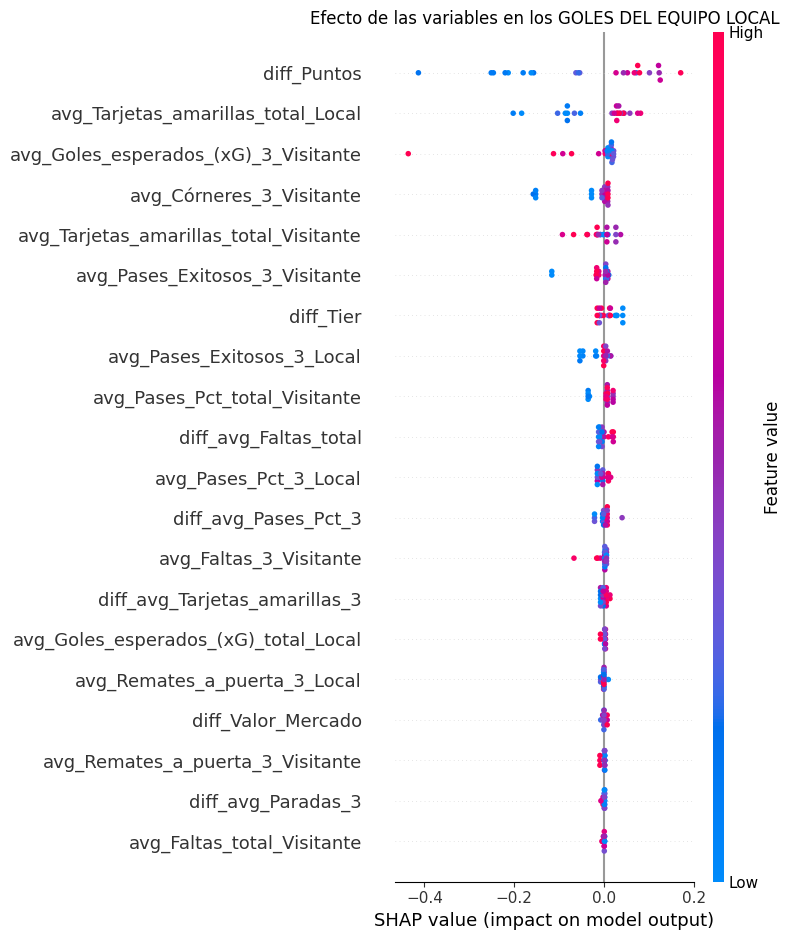

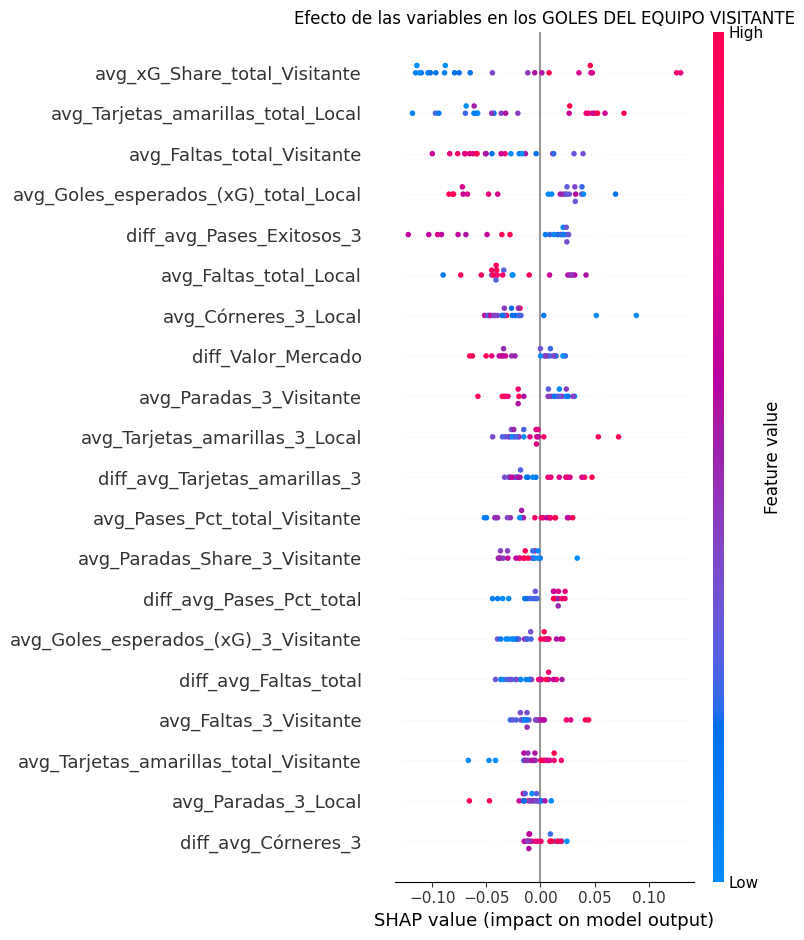

In [8]:
import matplotlib.pyplot as plt
import shap
import warnings

# TreeExplainer explota la estructura interna de XGBoost → instantáneo.
print("\nCalculando valores SHAP para Goles (TreeExplainer)...")

explainer_L = shap.TreeExplainer(mejor_modelo_L)
explainer_V = shap.TreeExplainer(mejor_modelo_V)

# Usamos todo X_test (sin necesidad de reducir muestra)
shap_values_L = explainer_L.shap_values(X_test)
shap_values_V = explainer_V.shap_values(X_test)

plt.figure(figsize=(10, 6))
plt.title("Efecto de las variables en los GOLES DEL EQUIPO LOCAL")
shap.summary_plot(shap_values_L, X_test, show=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.title("Efecto de las variables en los GOLES DEL EQUIPO VISITANTE")
shap.summary_plot(shap_values_V, X_test, show=False)
plt.tight_layout()
plt.show()



--- DIAGNÓSTICO DEL MODELO 1X2 ---

Top 15 Variables más determinantes:
                                Variable  Importancia
               diff_avg_Pases_Exitosos_3     0.048223
                      diff_Valor_Mercado     0.037581
    avg_Goles_esperados_(xG)_3_Visitante     0.037220
                             diff_Puntos     0.035883
             diff_avg_Remates_a_puerta_3     0.029261
    avg_Goles_esperados_(xG)_total_Local     0.029230
           avg_Pases_Pct_total_Visitante     0.029039
                   diff_avg_Faltas_total     0.028866
                   avg_Pases_Pct_3_Local     0.027635
       diff_avg_Tarjetas_amarillas_total     0.025019
avg_Goles_esperados_(xG)_total_Visitante     0.024229
  avg_Tarjetas_amarillas_total_Visitante     0.024075
          avg_Pases_Exitosos_3_Visitante     0.023125
              avg_Faltas_total_Visitante     0.023104
                            Pred_Goles_V     0.023049

Calculando valores SHAP para el clasificador 1X2 (TreeExplaine

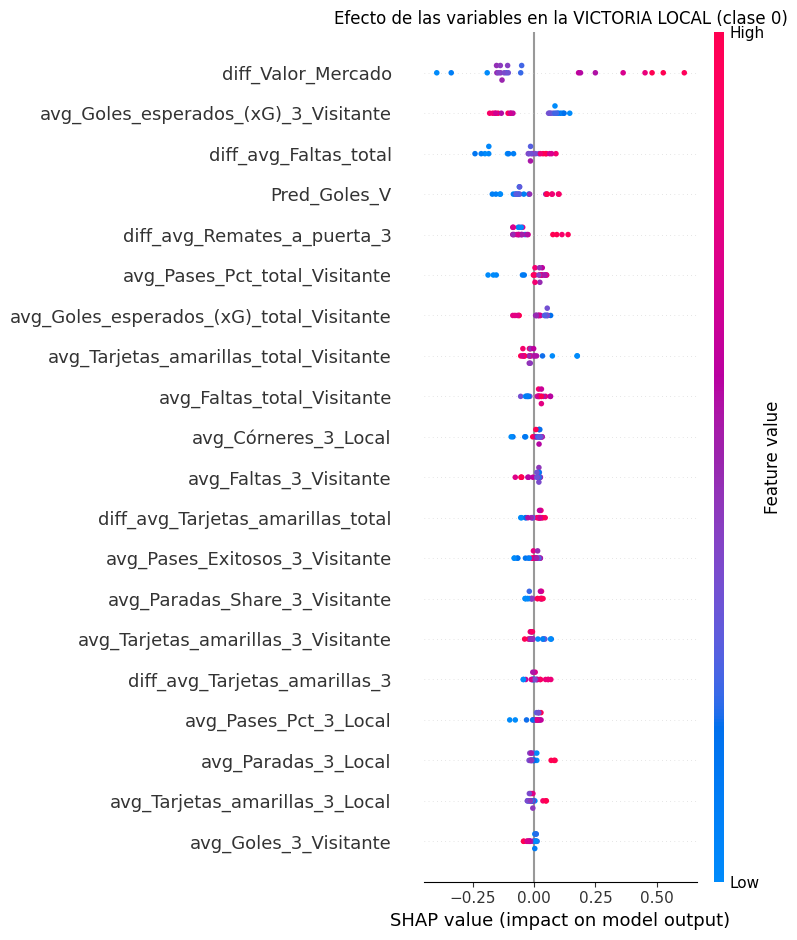

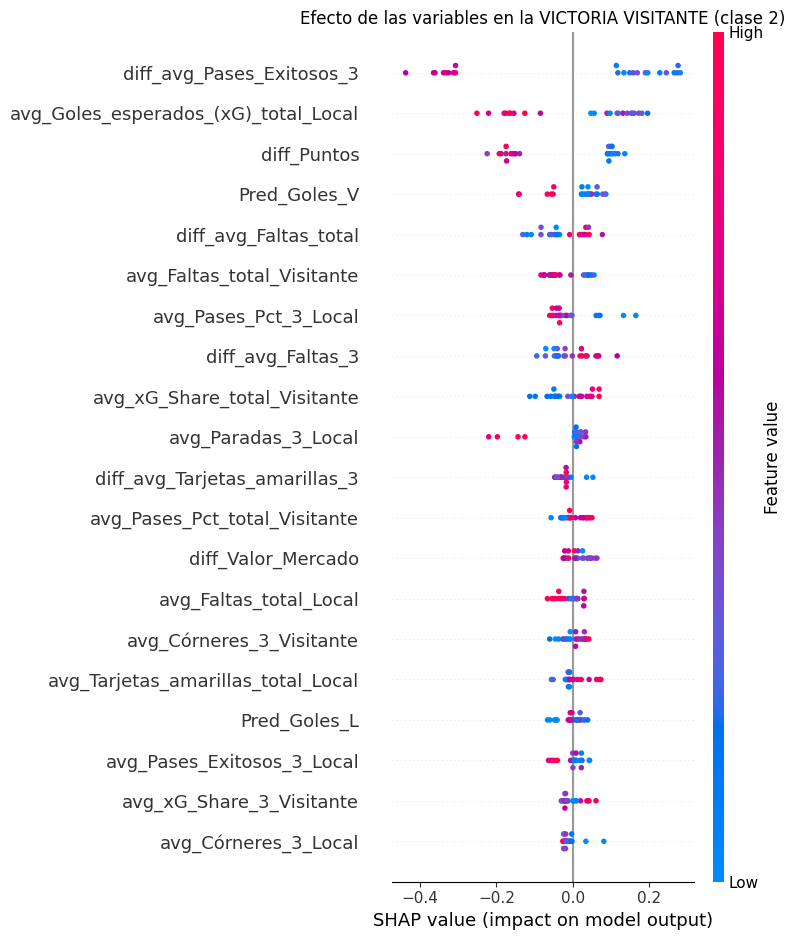

In [9]:
print("\n--- DIAGNÓSTICO DEL MODELO 1X2 ---")

# 1. IMPORTANCIA GLOBAL
importancias = mejor_clf.feature_importances_
columnas = X_train_meta.columns

df_importancia = pd.DataFrame({
    'Variable': columnas,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

print("\nTop 15 Variables más determinantes:")
print(df_importancia.head(15).to_string(index=False))

# OPTIMIZACIÓN: TreeExplainer para el clasificador.
# Nota: para modelos calibrados (CalibratedClassifierCV) usamos el estimador base.
print("\nCalculando valores SHAP para el clasificador 1X2 (TreeExplainer)...")
explainer_clf = shap.TreeExplainer(mejor_clf)
shap_values_clf = explainer_clf.shap_values(X_test_meta)

# shap_values_clf puede ser 3D (n_muestras, n_features, n_clases) o lista según versión
# Normalizamos a lista de matrices 2D:
if hasattr(shap_values_clf, 'ndim') and shap_values_clf.ndim == 3:
    shap_por_clase = [shap_values_clf[:, :, k] for k in range(shap_values_clf.shape[2])]
else:
    shap_por_clase = shap_values_clf  # ya es lista

plt.figure(figsize=(10, 6))
plt.title("Efecto de las variables en la VICTORIA LOCAL (clase 0)")
shap.summary_plot(shap_por_clase[0], X_test_meta, show=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.title("Efecto de las variables en la VICTORIA VISITANTE (clase 2)")
shap.summary_plot(shap_por_clase[2], X_test_meta, show=False)
plt.tight_layout()
plt.show()


### Evaluación en el Conjunto de Test

Se vuelcan las predicciones sobre $\mathcal{D}_{\text{test}}$ para auditar la matriz de confusión y las métricas de clasificación (precisión, *recall*, F1) por clase. Nótese que el desequilibrio natural de clases —victoria local es la más frecuente; empate la menos— hace que las métricas macro y ponderadas difieran; se reportan ambas.


In [10]:
df_test['Resultado_1X2_Pred'] = predicciones_finales
df_test['Prob_1'] = probabilidades_finales[:, 0]
df_test['Prob_X'] = probabilidades_finales[:, 1]
df_test['Prob_2'] = probabilidades_finales[:, 2]
df_test['Pred_Goles_L'] = pred_goles_L_test
df_test['Pred_Goles_V'] = pred_goles_V_test

df_test[['Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado_1X2', 'Goles_Local', 'Goles_Visitante', 'Pred_Goles_L', 'Pred_Goles_V', 'Resultado_1X2_Pred', 'Prob_1', 'Prob_X', 'Prob_2']].tail(10)

,Fecha,Equipo_Local,Equipo_Visitante,Resultado_1X2,Goles_Local,Goles_Visitante,Pred_Goles_L,Pred_Goles_V,Resultado_1X2_Pred,Prob_1,Prob_X,Prob_2
1371,2026-03-31,Marruecos,Paraguay,1,2.0,1.0,1.057716,0.552813,0,0.459410,0.361093,0.179497
1369,2026-03-31,Argelia,Uruguay,X,0.0,0.0,0.719336,1.154263,0,0.616227,0.114286,0.269487
1368,2026-03-31,Países Bajos,Ecuador,X,1.0,1.0,2.072570,0.532209,0,0.563654,0.436346,0.000000
1367,2026-03-31,Inglaterra,Japón,2,0.0,1.0,1.278517,0.860179,0,0.528401,0.463616,0.007984
1365,2026-03-31,España,Egipto,X,0.0,0.0,2.784305,0.520374,0,0.727731,0.272269,0.000000
1385,2026-04-01,EE. UU.,Portugal,2,0.0,2.0,0.805353,1.701126,2,0.351917,0.291352,0.356730
1386,2026-04-01,Canadá,Túnez,X,0.0,0.0,1.569312,0.854160,0,0.414888,0.294793,0.290319
1388,2026-04-01,Brasil,Croacia,1,3.0,1.0,2.593776,1.662957,0,0.438208,0.398484,0.163308
1389,2026-04-01,México,Bélgica,X,1.0,1.0,1.321230,1.986027,2,0.305253,0.284656,0.410091
1390,2026-05-23,México,Ghana,1,2.0,0.0,1.476548,0.350352,0,0.498604,0.112630,0.388766


In [11]:
pd.crosstab(df_test['Resultado_1X2_Pred'], df_test['Resultado_1X2'])

Resultado_1X2,1,2,X
Resultado_1X2_Pred,,,
0,4,3,6
1,0,3,1
2,1,2,3


# Pipeline de prediccón


## 6. Reentrenamiento con el 100% de los Datos

Una vez seleccionados los hiperparámetros y validado el rendimiento en test, se re-entrena el pipeline completo sobre **toda la muestra histórica** para maximizar la información disponible antes de predecir el torneo.

El procedimiento es idéntico al de la fase de ajuste, con dos salvedades:

1. Las meta-variables de goles $(\hat{\lambda}_L, \hat{\lambda}_V)$ se generan **out-of-fold** con `KFold(n_splits=5)` sobre el 100% de los datos, evitando *data leakage* al clasificador final.
2. La calibración isotónica se re-ajusta también sobre el 100%, con los mismos folds.

Los modelos resultantes $\hat{f}_L^*$, $\hat{f}_V^*$ y $\hat{g}^*$ se serializan en disco (`joblib`) para ser reutilizados en el pipeline de predicción sin necesidad de re-entrenar.



Los tres modelos entrenados se guardan en disco para poder aplicarlos directamente sobre los partidos del Mundial sin repetir el entrenamiento.

In [12]:
print("\n=======================================================")
print(" FASE DE PRODUCCIÓN: REENTRENANDO CON EL 100% DE DATOS")
print("=======================================================")

import joblib

# 'X' y 'y' (y_1X2) son tus datasets completos originales antes del split
y_goles_L_full = df['Goles_Local']
y_goles_V_full = df['Goles_Visitante']

# --- Novedad: Creación de pesos para el 100% de los datos ---
pesos_full_L = np.where(y_goles_L_full >= 3, 1.5, 1.0)
pesos_full_V = np.where(y_goles_V_full >= 3, 1.5, 1.0)

# --- 1. GENERAR META-VARIABLES SIN TRAMPAS (OOF en todo X) ---
# Usamos cross_val_predict para que el clasificador final aprenda
# usando proyecciones realistas con su margen de error.
print("1/4 Generando Goles Esperados para todo el histórico...")
kf_meta_full = KFold(n_splits=5, shuffle=False)

# Inyectamos los pesos con 'params'
pred_goles_L_full = cross_val_predict(mejor_modelo_L, X, y_goles_L_full, cv=kf_meta_full, params={'sample_weight': pesos_full_L})
pred_goles_V_full = cross_val_predict(mejor_modelo_V, X, y_goles_V_full, cv=kf_meta_full, params={'sample_weight': pesos_full_V})

X_meta_full = X.copy()
X_meta_full['Pred_Goles_L'] = pred_goles_L_full
X_meta_full['Pred_Goles_V'] = pred_goles_V_full
X_meta_full['Pred_Goles_L'] = X_meta_full['Pred_Goles_L']
X_meta_full['Pred_Goles_V'] = X_meta_full['Pred_Goles_V']


# Si añadiste el Ratio de Dominio, lo calculas aquí también:
# X_meta_full['Ratio_Dominio'] = X_meta_full['Pred_Goles_L'] / (X_meta_full['Pred_Goles_V'] + 0.1)

# --- 2. ENTRENAR LOS REGRESORES DE GOLES FINALES ---
# Ahora sí, los motores de goles memorizan y aprenden del 100% de los datos
print("2/4 Entrenando modelos de goles definitivos...")
mejor_modelo_L.fit(X, y_goles_L_full, sample_weight=pesos_full_L)
mejor_modelo_V.fit(X, y_goles_V_full, sample_weight=pesos_full_V)

# --- 3. CONFIGURAR EL CLASIFICADOR FINAL CON LOS MEJORES PARÁMETROS ---
print("3/4 Entrenando clasificador 1X2 definitivo...")
modelo_1X2_final = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    base_score=0.5,
    random_state=42,
    **search_clf.best_params_ # Inyectamos la configuración ganadora
)

# --- 4. CALIBRACIÓN FINAL EN EL 100% DE LOS DATOS ---
print("4/4 Calibrando probabilidades finales...")
clasificador_calibrado_final = CalibratedClassifierCV(
    estimator=modelo_1X2_final,
    method='isotonic',
    cv=tscv # Seguimos usando TimeSeriesSplit para la calibración interna
)
clasificador_calibrado_final.fit(X_meta_full, y)

print("¡Modelo Listo para el Mundial!")

# =====================================================================
# GUARDADO DE ARCHIVOS PARA EL PIPELINE
# =====================================================================
joblib.dump(mejor_modelo_L, 'modelo_goles_L.pkl')
joblib.dump(mejor_modelo_V, 'modelo_goles_V.pkl')
joblib.dump(clasificador_calibrado_final, 'modelo_1X2_calibrado.pkl')
joblib.dump(list(X.columns), 'columnas_entrenamiento.pkl')

print("Motores actualizados sobrescritos en el disco duro con éxito.")


 FASE DE PRODUCCIÓN: REENTRENANDO CON EL 100% DE DATOS
1/4 Generando Goles Esperados para todo el histórico...
2/4 Entrenando modelos de goles definitivos...
3/4 Entrenando clasificador 1X2 definitivo...
4/4 Calibrando probabilidades finales...
¡Modelo Listo para el Mundial!
Motores actualizados sobrescritos en el disco duro con éxito.


In [13]:
# Guardamos los tres modelos entrenados
joblib.dump(mejor_modelo_L, 'modelo_goles_L.pkl')
joblib.dump(mejor_modelo_V, 'modelo_goles_V.pkl')
joblib.dump(mejor_clf, 'modelo_1X2.pkl')
joblib.dump(clasificador_calibrado, 'modelo_1X2_calibrado.pkl')

# Guardamos también la lista exacta de variables independientes
# XGBoost colapsará si el nuevo dataset tiene las columnas en otro orden o le falta alguna
joblib.dump(list(X_train.columns), 'columnas_entrenamiento.pkl')

['columnas_entrenamiento.pkl']

# Predicciones para el Mundial


## 7. Predicciones en Sede Neutral y Ajuste por Temperatura

### 7.1 Eliminación del Sesgo de Campo

Los modelos se entrenaron con partidos en los que uno de los equipos es local y el otro visitante, absorbiendo implícitamente la ventaja de campo. En el Mundial todos los partidos se juegan en sede neutral. Para eliminar este sesgo se predice cada partido **dos veces** —con los roles intercambiados— y se promedian las probabilidades:

$$P_k^{\text{neutral}} = \frac{P_k^{(A \to B)} + P_{2-k}^{(B \to A)}}{2}, \qquad k \in \{0, 1, 2\}$$

donde el índice $2-k$ invierte la perspectiva local/visitante en la segunda predicción.

### 7.2 Sharpening por Temperatura

Los modelos calibrados tienden a producir probabilidades conservadoras (cercanas a la base rate de cada clase). Para intensificar las diferencias entre favorito y no favorito se aplica un **ajuste de temperatura** $T$:

$$\tilde{p}_k = \frac{p_k^{1/T}}{\displaystyle\sum_{j=0}^{2} p_j^{1/T}}, \qquad T = 0.27$$

Con $T < 1$ la distribución se vuelve más puntiaguda (*sharper*): una probabilidad de $0.50$ se transforma aproximadamente en $0.67$, y una de $0.30$ en $0.13$. Con $T = 1$ la transformación es la identidad. El valor $T = 0.27$ se fijó empíricamente para que las probabilidades implícitas sean coherentes con las de mercados de apuestas líquidos.


In [14]:
# Variables y funciones auxiliares que utilizamos en la ingeniería de variables (para incluirla en los partidos el mundial).

def asignar_tier(puntos):
    if puntos >= 1700: return 1   # Élite (Francia, Argentina, España...)
    elif puntos >= 1600: return 2 # Nivel Alto (Suiza, Senegal, Japón...)
    elif puntos >= 1500: return 3 # Nivel Medio (Haití, Jordania...)
    else: return 4                # Nivel Bajo (Curazao, etc.)

mapa_continentes = {
    # EUROPA (UEFA)
    'República Checa': 'Europa', 'Bosnia-Herzegovina': 'Europa', 'Suiza': 'Europa',
    'Países Bajos': 'Europa', 'Alemania': 'Europa', 'Escocia': 'Europa',
    'Turquía': 'Europa', 'Suecia': 'Europa', 'España': 'Europa',
    'Bélgica': 'Europa', 'Francia': 'Europa', 'Croacia': 'Europa',
    'Austria': 'Europa', 'Portugal': 'Europa', 'Inglaterra': 'Europa',
    'Noruega': 'Europa',

    # SUDAMÉRICA (CONMEBOL)
    'Paraguay': 'Sudamérica', 'Brasil': 'Sudamérica', 'Ecuador': 'Sudamérica',
    'Uruguay': 'Sudamérica', 'Argentina': 'Sudamérica', 'Colombia': 'Sudamérica',

    # NORTEAMÉRICA Y CARIBE (CONCACAF)
    'México': 'Norteamérica', 'Canadá': 'Norteamérica', 'EE. UU.': 'Norteamérica',
    'Haití': 'Norteamérica', 'Curazao': 'Norteamérica', 'Panamá': 'Norteamérica',

    # ÁFRICA (CAF)
    'Sudáfrica': 'Africa', 'Marruecos': 'Africa', 'Egipto': 'Africa',
    'Túnez': 'Africa', 'Costa de Marfil': 'Africa', 'Cabo Verde': 'Africa',
    'Senegal': 'Africa', 'RD Congo': 'Africa', 'Argelia': 'Africa',
    'Ghana': 'Africa',

    # ASIA (AFC) - Nota: Australia compite deportivamente en Asia
    'Corea del Sur': 'Asia', 'Catar': 'Asia', 'Japón': 'Asia',
    'Australia': 'Asia', 'Irán': 'Asia', 'Arabia Saudí': 'Asia',
    'Jordania': 'Asia', 'Irak': 'Asia', 'Uzbekistán': 'Asia',
    'Nueva Zelanda': 'Asia'
}

pesos_continente = {
    'Europa': 1.00,       # No se descuenta nada
    'Sudamérica': .95,   # Se descuenta un 5%
    'Norteamérica': 0.75, # Se les quita un 25% de su poder ofensivo
    'Africa': 0.6,
    'Asia': 0.7,         # Se les quita un 30%
    'Oceanía': 0.5       # Sus medias valen la mitad en un Mundial
}

El parámetro `T` puede modificarse para explorar distintos niveles de agresividad en las predicciones. Valores más bajos polarizan más las probabilidades; `T=1` devuelve las probabilidades calibradas sin transformar. En las simulaciones de producción se usa `T=0.27`.

In [15]:
# ====================================================================
# 2. PIPELINE DE PREDICCIÓN DEFINITIVO
# ====================================================================

def pipeline_prediccion(df_bruto, sede_neutral=True, T=0.5):
    # Carga de modelos
    modelo_L = joblib.load('modelo_goles_L.pkl')
    modelo_V = joblib.load('modelo_goles_V.pkl')
    modelo_1X2 = joblib.load('modelo_1X2_calibrado.pkl')
    columnas_base = joblib.load('columnas_entrenamiento.pkl')

    def obtener_predicciones_crudas(df_temp):
        df_calc = df_temp.copy()

        # Diferencias
        columnas_promedios_local = [col for col in df_calc.columns if col.endswith(('_5_Local', '_2_Local', '_total_Local')) and col.startswith('avg_')]
        for col_local in columnas_promedios_local:
            col_visitante = col_local.replace('_Local', '_Visitante')
            if col_visitante in df_calc.columns:
                nombre_base = col_local.replace('_Local', '')
                df_calc[f"diff_{nombre_base}"] = df_calc[col_local] - df_calc[col_visitante]

        if 'Puntos_Local' in df_calc.columns and 'Puntos_Visitante' in df_calc.columns:
            df_calc['diff_Puntos'] = df_calc['Puntos_Local'] - df_calc['Puntos_Visitante']
            df_calc['Prob_Implicita_ELO'] = 1 / (1 + 10 ** (-df_calc['diff_Puntos'] / 400))
            df_calc['diff_Tier'] = df_calc['Puntos_Local'].apply(asignar_tier) - df_calc['Puntos_Visitante'].apply(asignar_tier)

        # Continentes y Pesos
        df_calc['Continente_Local'] = df_calc['Equipo_Local'].map(mapa_continentes)
        df_calc['Continente_Visitante'] = df_calc['Equipo_Visitante'].map(mapa_continentes)
        df_calc['Peso_Local'] = df_calc['Continente_Local'].map(pesos_continente)
        df_calc['Peso_Visitante'] = df_calc['Continente_Visitante'].map(pesos_continente)

        # EL FIX IMPORTANTE AQUÍ:
        df_calc.drop(['Continente_Local', 'Continente_Visitante'], axis=1, inplace=True)

        # Rellenar y alinear
        for col in columnas_base:
            if col not in df_calc.columns:
                df_calc[col] = 0
        X_listo = df_calc[columnas_base]

        # Predicciones
        goles_L = modelo_L.predict(X_listo) # ** 1.5 * X_listo['Peso_Local']
        goles_V = modelo_V.predict(X_listo) # ** 1.5 * X_listo['Peso_Visitante']

        X_meta = X_listo.copy()
        X_meta['Pred_Goles_L'] = goles_L
        X_meta['Pred_Goles_V'] = goles_V
        probs = modelo_1X2.predict_proba(X_meta)

        return goles_L, goles_V, probs

    # --- PREDICCIÓN NORMAL Y ESPEJO ---
    df_normal = df_bruto.copy()

    # Dejamos pasar el Grupo si existe
    cols_contexto = ['Fecha', 'Equipo_Local', 'Equipo_Visitante']
    if 'Grupo' in df_normal.columns:
        cols_contexto.append('Grupo')

    contexto = df_normal[cols_contexto].copy()

    goles_L_norm, goles_V_norm, probs_norm = obtener_predicciones_crudas(df_normal)

    if not sede_neutral:
        resultados = contexto.copy()
        resultados['xG_Modelo_Local'] = goles_L_norm.round(2)
        resultados['xG_Modelo_Visitante'] = goles_V_norm.round(2)
        resultados['Prob_VLocal'] = probs_norm[:, 0]
        resultados['Prob_Empate'] = probs_norm[:, 1]
        resultados['Prob_Visitante'] = probs_norm[:, 2]
        return resultados

    df_inverso = df_bruto.copy()
    nuevas_columnas = []
    for col in df_inverso.columns:
        if col.endswith('_Local'): nuevas_columnas.append(col.replace('_Local', '_Visitante'))
        elif col.endswith('_Visitante'): nuevas_columnas.append(col.replace('_Visitante', '_Local'))
        else: nuevas_columnas.append(col)

    df_inverso.columns = nuevas_columnas
    goles_L_inv, goles_V_inv, probs_inv = obtener_predicciones_crudas(df_inverso)

    # --- SÍNTESIS ---
    resultados = contexto.copy()
    resultados['xG_Modelo_Local'] = ((goles_L_norm + goles_V_inv) / 2).round(2)
    resultados['xG_Modelo_Visitante'] = ((goles_V_norm + goles_L_inv) / 2).round(2)

    resultados['Prob_Local'] = (probs_norm[:, 0] + probs_inv[:, 2]) / 2
    resultados['Prob_Empate'] = (probs_norm[:, 1] + probs_inv[:, 1]) / 2
    resultados['Prob_Visitante'] = (probs_norm[:, 2] + probs_inv[:, 0]) / 2

    # Afilado por temperatura
    probs_afiladas = resultados[['Prob_Local', 'Prob_Empate', 'Prob_Visitante']] ** (1 / T)
    s = probs_afiladas.sum(axis=1).replace(0, 1e-12)
    resultados[['Prob_Local', 'Prob_Empate', 'Prob_Visitante']] = probs_afiladas.div(s, axis=0)

    return resultados

In [16]:
# Ejemplo de ejecucion (puedes jugar con T para ver como funcinoa)
df_predicciones = pipeline_prediccion(df, T = 0.3)
df_predicciones.tail()

,Fecha,Equipo_Local,Equipo_Visitante,xG_Modelo_Local,xG_Modelo_Visitante,Prob_Local,Prob_Empate,Prob_Visitante
1385,2026-04-01,EE. UU.,Portugal,0.95,1.47,0.101190,0.415685,0.483126
1386,2026-04-01,Canadá,Túnez,1.15,1.03,0.647930,0.155291,0.196779
1388,2026-04-01,Brasil,Croacia,1.36,1.29,0.175286,0.577178,0.247536
1389,2026-04-01,México,Bélgica,1.27,1.22,0.152983,0.326916,0.520101
1390,2026-05-23,México,Ghana,1.31,0.90,0.407108,0.079078,0.513814


# Simulaciones de Monte Carlo

## 8. Simulación Monte Carlo del Torneo

### 8.1 Motivación

Una sola simulación determinista del torneo (asignando siempre el resultado de mayor probabilidad) ignora la varianza inherente del fútbol: un equipo con $p_{\text{victoria}} = 0.51$ y otro con $p = 0.99$ producirían el mismo resultado determinista. La simulación estocástica captura esta incertidumbre.

### 8.2 Mecanismo de Simulación

En cada uno de los $N = 1{,}000$ torneos simulados, el resultado de cada partido se extrae de una distribución multinomial:

$$\text{Resultado}_i \sim \text{Multinomial}\!\left(1;\; p_L^{(i)},\; p_X^{(i)},\; p_V^{(i)}\right)$$

En las rondas eliminatorias no puede haber empate en 90 minutos. Si el sorteo produce $X$, el clasificado se decide por penaltis con probabilidad proporcional a las probabilidades de victoria en tiempo regular:

$$p_{\text{pen}}(L) = \frac{p_L}{p_L + p_V}, \qquad p_{\text{pen}}(V) = 1 - p_{\text{pen}}(L)$$

### 8.3 Fase de Grupos (ya disputada)

La fase de grupos del Mundial 2026 ya fue jugada. Los 16 cruces de dieciseisavos de final son los clasificados reales, por lo que **no se simulan** los 72 partidos de grupos: las simulaciones Monte Carlo parten directamente de los cruces confirmados por la FIFA el 28 de junio de 2026.

### 8.4 Estimación de Probabilidades por Ronda

La probabilidad de que el equipo $e$ alcance o supere la ronda $r$ se estima por frecuencia relativa sobre los $N$ torneos:

$$\hat{P}(\text{equipo } e \text{ alcanza ronda } r) = \frac{1}{N} \sum_{n=1}^{N} \mathbf{1}\!\left[\text{fase}_{e,n} \geq r\right]$$

El error estándar de Monte Carlo decrece como $\mathcal{O}(N^{-1/2})$; con $N = 1{,}000$ se obtiene un margen de $\pm 1.6$ puntos porcentuales al 95% de confianza para probabilidades cercanas al 50%.

### 8.5 Implementación Eficiente

Las $N$ simulaciones son independientes entre sí, lo que permite parelelizarlas trivialmente. Se usa `joblib.Parallel(n_jobs=-1, backend='loky')` para distribuirlas sobre todos los núcleos disponibles en el entorno de ejecución (Colab proporciona típicamente 2–4 núcleos), obteniendo un *speedup* aproximado de $2\times$–$4\times$ respecto al bucle secuencial.



Se cargan las covariables de cada selección (`datos_mundial.csv`) para que el pipeline de predicción pueda construir los vectores de características de cada cruce eliminatorio. La fase de grupos ya concluyó; no es necesario cargar el fixture de grupos.

In [17]:
# ====================================================================
# CARGA DE DATOS PARA ELIMINATORIAS
# La fase de grupos ya jugó: solo necesitamos las covariables de cada
# selección (datos_mundial.csv) para predecir los cruces de R32 en adelante.
# ====================================================================

# Dataset con las covariables de cada selección (forma reciente, ranking, etc.)
df_vars = pd.read_csv(f'{base_path}/datos_mundial.csv').sort_values('Fecha')

print(f"Selecciones en datos_mundial: {len(df_vars)}")
print(f"Columnas: {list(df_vars.columns[:5])} ...")
print("\nSelecciones disponibles:")
print(sorted(df_vars['Equipo'].tolist()))


Selecciones en datos_mundial: 48
Columnas: ['Equipo', 'Puntos', 'Peso', 'Valor_Mercado_Millones_Eur', 'Tipo_Equipo'] ...

Selecciones disponibles:
['Alemania', 'Arabia Saudí', 'Argelia', 'Argentina', 'Australia', 'Austria', 'Bosnia-Herzegovina', 'Brasil', 'Bélgica', 'Cabo Verde', 'Canadá', 'Catar', 'Colombia', 'Corea del Sur', 'Costa de Marfil', 'Croacia', 'Curazao', 'EE. UU.', 'Ecuador', 'Egipto', 'Escocia', 'España', 'Francia', 'Ghana', 'Haití', 'Inglaterra', 'Irak', 'Irán', 'Japón', 'Jordania', 'Marruecos', 'México', 'Noruega', 'Nueva Zelanda', 'Panamá', 'Paraguay', 'Países Bajos', 'Portugal', 'RD Congo', 'República Checa', 'Senegal', 'Sudáfrica', 'Suecia', 'Suiza', 'Turquía', 'Túnez', 'Uruguay', 'Uzbekistán']


Se definen dos funciones principales:

- `simular_cruce(equipo_L, equipo_V, ...)` — construye el vector de covariables del partido, llama al pipeline de predicción y extrae un ganador muestreando de la distribución multinomial resultante. En caso de empate resuelve por penaltis según la ecuación de proporcionalidad descrita en §8.2.

- `simular_mundial_completo(cruces_r32, ...)` — recorre el cuadro completo desde R32 hasta la final, llamando a `simular_cruce` en cada enfrentamiento y registrando la fase máxima alcanzada por cada selección.

Los cruces de R32 se pasan como argumento para poder inyectar los 16 emparejamientos reales confirmados por la FIFA.

In [18]:
from collections import defaultdict

# =====================================================================
# CRUCES REALES DE R32 (fase de grupos ya jugada - Mundial 2026)
# Fuente: FIFA / confirmados el 28 de junio de 2026
# =====================================================================
CRUCES_R32_REALES = [
    ("Sudáfrica",        "Canadá"),
    ("Brasil",           "Japón"),
    ("Alemania",         "Paraguay"),
    ("Países Bajos",     "Marruecos"),
    ("Costa de Marfil",  "Noruega"),
    ("Francia",          "Suecia"),
    ("México",           "Ecuador"),
    ("Inglaterra",       "RD Congo"),
    ("Bélgica",          "Senegal"),
    ("EE. UU.",          "Bosnia-Herzegovina"),
    ("España",           "Austria"),
    ("Portugal",         "Croacia"),
    ("Suiza",            "Argelia"),
    ("Australia",        "Egipto"),
    ("Argentina",        "Cabo Verde"),
    ("Colombia",         "Ghana"),
]

def simular_cruce(equipo_L, equipo_V, modelo_pipeline, df_base_variables):
    """Simula un cruce eliminatorio estocástico y devuelve (Ganador, Perdedor)."""
    partido = pd.DataFrame({'Fecha': ['2026-07-01'], 'Equipo_Local': [equipo_L], 'Equipo_Visitante': [equipo_V]})

    partido_vars = partido.merge(df_base_variables, left_on='Equipo_Local', right_on='Equipo', how='left').drop(columns=['Equipo'])
    partido_vars = partido_vars.merge(df_base_variables, left_on='Equipo_Visitante', right_on='Equipo', how='left', suffixes=('_Local', '_Visitante')).drop(columns=['Equipo'])

    try:
        df_pred = modelo_pipeline(partido_vars, sede_neutral=True)
        probs = [df_pred['Prob_Local'].iloc[0], df_pred['Prob_Empate'].iloc[0], df_pred['Prob_Visitante'].iloc[0]]
    except:
        probs = [0.40, 0.20, 0.40]

    resultado = np.random.choice([0, 1, 2], p=probs)

    if resultado == 1:
        p1_pen = probs[0] / (probs[0] + probs[2])
        resultado = np.random.choice([0, 2], p=[p1_pen, 1 - p1_pen])

    return (equipo_L, equipo_V) if resultado == 0 else (equipo_V, equipo_L)


def simular_mundial_completo(cruces_r32, modelo_pipeline, df_vars):
    """
    Ejecuta un Mundial desde R32 en adelante.
    NOTA: La fase de grupos ya jugó — los cruces de R32 son los reales.
    Se pasa cruces_r32 como argumento para poder inyectar los reales.
    """
    progreso = {}

    # --- R32: Dieciseisavos (cruces reales, ya no simulamos grupos) ---
    ganadores_r32 = []
    for eq_L, eq_V in cruces_r32:
        w, l = simular_cruce(eq_L, eq_V, modelo_pipeline, df_vars)
        ganadores_r32.append(w)
        progreso[w] = 'Octavos'
        progreso[l] = 'R32'  # El perdedor queda en R32

    # --- Octavos (R16): pares consecutivos de ganadores de R32 ---
    ganadores_r16 = []
    for i in range(0, 16, 2):
        w, l = simular_cruce(ganadores_r32[i], ganadores_r32[i+1], modelo_pipeline, df_vars)
        ganadores_r16.append(w)
        progreso[w] = 'Cuartos'

    # --- Cuartos (QF) ---
    ganadores_qf = []
    for i in range(0, 8, 2):
        w, l = simular_cruce(ganadores_r16[i], ganadores_r16[i+1], modelo_pipeline, df_vars)
        ganadores_qf.append(w)
        progreso[w] = 'Semis'

    # --- Semifinales ---
    sf1_w, sf1_l = simular_cruce(ganadores_qf[0], ganadores_qf[1], modelo_pipeline, df_vars)
    sf2_w, sf2_l = simular_cruce(ganadores_qf[2], ganadores_qf[3], modelo_pipeline, df_vars)
    progreso[sf1_w] = 'Final'
    progreso[sf2_w] = 'Final'

    # --- Final ---
    campeon, subcampeon = simular_cruce(sf1_w, sf2_w, modelo_pipeline, df_vars)
    progreso[campeon] = 'Campeon'

    return progreso


In [19]:
    from tqdm import tqdm
from joblib import Parallel, delayed

# =====================================================================
# OPTIMIZACIÓN: Monte Carlo paralelizado con joblib.Parallel
# La fase de grupos ya jugó → partimos directamente de los cruces reales de R32.
# n_jobs=-1 usa todos los cores disponibles en Colab → speedup ~2-4x.
# =====================================================================

def _simular_uno(cruces_r32, modelo_pipeline, df_vars):
    """Un único mundial desde R32. Función a nivel de módulo para joblib."""
    return simular_mundial_completo(cruces_r32, modelo_pipeline, df_vars)


def ejecutar_monte_carlo(cruces_r32, modelo, df_vars, n_simulaciones=1000, n_jobs=-1):
    print(f"Iniciando Matrix: {n_simulaciones} Mundiales (n_jobs={n_jobs})...")

    resultados = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(_simular_uno)(cruces_r32, modelo, df_vars)
        for _ in tqdm(range(n_simulaciones))
    )

    stats = defaultdict(lambda: {'R32': 0, 'Octavos': 0, 'Cuartos': 0, 'Semis': 0, 'Final': 0, 'Campeon': 0})
    orden = ['R32', 'Octavos', 'Cuartos', 'Semis', 'Final', 'Campeon']

    for progreso_mundial in resultados:
        for equipo, fase_alcanzada in progreso_mundial.items():
            idx = orden.index(fase_alcanzada)
            for fase in orden[:idx + 1]:
                stats[equipo][fase] += 1

    df_resultados = pd.DataFrame.from_dict(stats, orient='index')
    df_resultados = (df_resultados / n_simulaciones) * 100
    df_resultados = df_resultados.sort_values(by=['Campeon', 'Final', 'Semis'], ascending=False).round(1)

    return df_resultados


# --- EJECUCIÓN ---
# Ya no se necesita pipeline_prediccion sobre grupos: usamos los cruces reales.
estadisticas_mundial = ejecutar_monte_carlo(
    cruces_r32=CRUCES_R32_REALES,
    modelo=pipeline_prediccion,
    df_vars=df_vars,
    n_simulaciones=1000,
    n_jobs=-1
)

print("\n🏆 PROBABILIDADES DEL MUNDIAL 2026 (%) 🏆")
print(estadisticas_mundial.head(20))


IndentationError: expected an indented block after function definition on line 10 (3879495972.py, line 11)

### Auditoría de los Cruces de Dieciseisavos (R32)

Se realiza una única tirada estocástica sobre los 16 cruces de R32 para mostrar, partido a partido, las probabilidades estimadas por el modelo ($p_L$, $p_X$, $p_V$), los goles esperados ($\hat{\lambda}_L$, $\hat{\lambda}_V$) y el resultado muestreado. Obsérvese que el resultado simulado no tiene por qué coincidir con el de mayor probabilidad: este es precisamente el mecanismo que captura la varianza del torneo. Cada ejecución produce una realización diferente.

In [ ]:
# =====================================================================
# AUDITORÍA R32 — una tirada estocástica sobre los cruces reales
# (La fase de grupos ya jugó; auditamos desde dieciseisavos en adelante)
# =====================================================================

pd.set_option('display.max_rows', 50)

# 1. Generar predicciones base para los 16 cruces de R32
filas = []
for eq_L, eq_V in CRUCES_R32_REALES:
    partido = pd.DataFrame({'Fecha': ['2026-07-01'], 'Equipo_Local': [eq_L], 'Equipo_Visitante': [eq_V]})
    partido_vars = partido.merge(df_vars, left_on='Equipo_Local',    right_on='Equipo', how='left').drop(columns=['Equipo'])
    partido_vars = partido_vars.merge(df_vars, left_on='Equipo_Visitante', right_on='Equipo', how='left', suffixes=('_Local', '_Visitante')).drop(columns=['Equipo'])
    try:
        pred = pipeline_prediccion(partido_vars, sede_neutral=True)
        prob_L = pred['Prob_Local'].iloc[0]
        prob_X = pred['Prob_Empate'].iloc[0]
        prob_V = pred['Prob_Visitante'].iloc[0]
        xg_L   = pred['xG_Modelo_Local'].iloc[0]
        xg_V   = pred['xG_Modelo_Visitante'].iloc[0]
    except:
        prob_L, prob_X, prob_V = 0.40, 0.20, 0.40
        xg_L, xg_V = 1.0, 1.0

    filas.append({'Fase': 'R32', 'Equipo_Local': eq_L, 'Equipo_Visitante': eq_V,
                  'xG_Modelo_Local': round(xg_L, 2), 'xG_Modelo_Visitante': round(xg_V, 2),
                  'Prob_Local': round(prob_L, 2), 'Prob_Empate': round(prob_X, 2), 'Prob_Visitante': round(prob_V, 2)})

df_auditoria = pd.DataFrame(filas)

# 2. Una tirada estocástica por partido
tiradas = []
for _, row in df_auditoria.iterrows():
    probs = np.array([row['Prob_Local'], row['Prob_Empate'], row['Prob_Visitante']])
    probs /= probs.sum()
    tiradas.append(np.random.choice(['1 (Local)', 'X (Empate)', '2 (Visitante)'], p=probs))

df_auditoria['Resultado_Simulado'] = tiradas

# 3. Mostrar
columnas_visibles = ['Fase', 'Equipo_Local', 'Equipo_Visitante',
                     'xG_Modelo_Local', 'xG_Modelo_Visitante',
                     'Prob_Local', 'Prob_Empate', 'Prob_Visitante', 'Resultado_Simulado']
df_auditoria[columnas_visibles]

### Auditoría del Cuadro Eliminatorio Completo

Se simula un único torneo desde R32 hasta la final, registrando para cada partido la fase, los equipos, los goles esperados, las probabilidades del modelo, el resultado en 90 minutos y si hubo penaltis. Esta vista permite auditar la coherencia del modelo cruce a cruce y detectar posibles anomalías antes de lanzar las $N = 1{,}000$ simulaciones completas.

In [ ]:
def auditar_eliminatorias_detallado(cruces_r32, modelo_pipeline, df_vars):
    """Juega un Mundial estocástico desde R32 y registra cruces con xG y probabilidades."""

    registro_cuadro = []

    def jugar_y_registrar_detalle(ronda, equipo_L, equipo_V):
        partido = pd.DataFrame({'Fecha': ['2026-07-01'], 'Equipo_Local': [equipo_L], 'Equipo_Visitante': [equipo_V]})
        partido_vars = partido.merge(df_vars, left_on='Equipo_Local', right_on='Equipo', how='left').drop(columns=['Equipo'])
        partido_vars = partido_vars.merge(df_vars, left_on='Equipo_Visitante', right_on='Equipo', how='left', suffixes=('_Local', '_Visitante')).drop(columns=['Equipo'])

        try:
            df_pred = modelo_pipeline(partido_vars, sede_neutral=True)
            prob_L = df_pred['Prob_Local'].iloc[0]
            prob_X = df_pred['Prob_Empate'].iloc[0]
            prob_V = df_pred['Prob_Visitante'].iloc[0]
            xg_L   = df_pred['xG_Modelo_Local'].iloc[0]
            xg_V   = df_pred['xG_Modelo_Visitante'].iloc[0]
        except:
            prob_L, prob_X, prob_V = 0.40, 0.20, 0.40
            xg_L, xg_V = 1.0, 1.0

        probs    = [prob_L, prob_X, prob_V]
        resultado = np.random.choice([0, 1, 2], p=probs)

        nota = "Tiempo Regular"
        if resultado == 1:
            nota = "Ganado en Penaltis"
            p1_pen = prob_L / (prob_L + prob_V)
            resultado_final = np.random.choice([0, 2], p=[p1_pen, 1 - p1_pen])
            ganador = equipo_L if resultado_final == 0 else equipo_V
            desenlace_90min = "Empate"
        else:
            desenlace_90min = equipo_L if resultado == 0 else equipo_V
            ganador = desenlace_90min

        registro_cuadro.append({
            'Fase': ronda,
            'Local': equipo_L, 'Visitante': equipo_V,
            'xG_L': round(xg_L, 2), 'xG_V': round(xg_V, 2),
            'Prob_L (%)': round(prob_L * 100, 1),
            'Prob_X (%)': round(prob_X * 100, 1),
            'Prob_V (%)': round(prob_V * 100, 1),
            'Resultado 90min': desenlace_90min,
            'Avanza Rda': ganador,
            'Detalle': nota
        })
        return ganador

    # --- R32 con los cruces reales ---
    ganadores_r32 = [jugar_y_registrar_detalle('1 - Dieciseisavos', L, V) for L, V in cruces_r32]

    # --- Octavos ---
    ganadores_r16 = []
    for i in range(0, 16, 2):
        ganadores_r16.append(jugar_y_registrar_detalle('2 - Octavos', ganadores_r32[i], ganadores_r32[i+1]))

    # --- Cuartos ---
    ganadores_qf = []
    for i in range(0, 8, 2):
        ganadores_qf.append(jugar_y_registrar_detalle('3 - Cuartos', ganadores_r16[i], ganadores_r16[i+1]))

    # --- Semifinales ---
    sf1_w = jugar_y_registrar_detalle('4 - Semifinales', ganadores_qf[0], ganadores_qf[1])
    sf2_w = jugar_y_registrar_detalle('4 - Semifinales', ganadores_qf[2], ganadores_qf[3])

    # --- Final ---
    jugar_y_registrar_detalle('5 - Final', sf1_w, sf2_w)

    return pd.DataFrame(registro_cuadro)


# EJECUCIÓN
df_cuadro_detallado = auditar_eliminatorias_detallado(CRUCES_R32_REALES, pipeline_prediccion, df_vars)
df_cuadro_detallado


# Predicciones Ganador Mundial


## 9. Resultados: Probabilidades de Campeón
La tabla muestra, para cada selección clasificada a R32, la probabilidad estimada de alcanzar cada ronda del torneo expresada en porcentaje. Las columnas son acumulativas: la probabilidad de llegar a Cuartos incluye haber superado R32 y Octavos.

Las probabilidades de campeón reflejan tanto la calidad estimada del equipo (a través de las covariables del modelo) como la dificultad esperada del camino en el cuadro (a través de las $N$ simulaciones). Equipos en la misma parte del cuadro compiten entre sí por las plazas de semifinales, lo que puede deprimir la probabilidad de campeonato de selecciones fuertes que comparten zona con otros favoritos.

In [ ]:
estadisticas_mundial.sort_values('Campeon', ascending=False)